In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import fetch_kddcup99 #fetch_kddcup99: 유명한 네트워크 데이터
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

In [5]:
RANDOM_STATE = 42

In [6]:
# ============================================================
# 0. KDD Cup 99 feature 설명
# ============================================================
# KDD99 데이터는 네트워크 connection 1건을 41개 feature로 표현합니다.
#
# 행(row) 1개 = 네트워크 connection 1건
# 컬럼(column) 1개 = connection을 설명하는 feature
#
# label:
# - normal. = 정상 트래픽
# - normal. 이외 = 공격 / 이상 트래픽
#
# 이 예제에서는 label을 다음처럼 바꿉니다.
# - 0 = normal
# - 1 = anomaly

feature_descriptions = {
    # Basic features
    "duration": "connection 지속 시간, 초 단위",
    "protocol_type": "프로토콜 종류. 예: tcp, udp, icmp",
    "service": "대상 네트워크 서비스. 예: http, smtp, ftp 등",
    "flag": "connection 상태 flag. 예: SF, S0, REJ 등",
    "src_bytes": "source에서 destination으로 보낸 byte 수",
    "dst_bytes": "destination에서 source로 보낸 byte 수",
    "land": "source/destination IP와 port가 모두 같으면 1",
    "wrong_fragment": "잘못된 fragment 수",
    "urgent": "urgent packet 수",

    # Content features
    "hot": "보안상 민감한 동작 indicator 수",
    "num_failed_logins": "로그인 실패 횟수",
    "logged_in": "로그인 성공 여부",
    "num_compromised": "compromised condition 수",
    "root_shell": "root shell 획득 여부",
    "su_attempted": "su root 명령 시도 여부",
    "num_root": "root access 수",
    "num_file_creations": "파일 생성 횟수",
    "num_shells": "shell prompt 획득 횟수",
    "num_access_files": "access control file 접근 횟수",
    "num_outbound_cmds": "outbound command 수",
    "is_host_login": "host login 여부",
    "is_guest_login": "guest login 여부",

    # Time-based traffic features
    "count": "최근 2초 동안 같은 destination host로의 connection 수",
    "srv_count": "최근 2초 동안 같은 service로의 connection 수",
    "serror_rate": "SYN error connection 비율",
    "srv_serror_rate": "같은 service 대상 SYN error 비율",
    "rerror_rate": "REJ error connection 비율",
    "srv_rerror_rate": "같은 service 대상 REJ error 비율",
    "same_srv_rate": "같은 service connection 비율",
    "diff_srv_rate": "다른 service connection 비율",
    "srv_diff_host_rate": "같은 service 중 다른 host로 향한 비율",

    # Host-based traffic features
    "dst_host_count": "최근 100개 connection 중 같은 destination host 수",
    "dst_host_srv_count": "최근 100개 connection 중 같은 destination host와 service 수",
    "dst_host_same_srv_rate": "destination host 기준 같은 service 비율",
    "dst_host_diff_srv_rate": "destination host 기준 다른 service 비율",
    "dst_host_same_src_port_rate": "destination host 기준 같은 source port 비율",
    "dst_host_srv_diff_host_rate": "destination host/service 기준 다른 host 비율",
    "dst_host_serror_rate": "destination host 기준 SYN error 비율",
    "dst_host_srv_serror_rate": "destination host/service 기준 SYN error 비율",
    "dst_host_rerror_rate": "destination host 기준 REJ error 비율",
    "dst_host_srv_rerror_rate": "destination host/service 기준 REJ error 비율",
}

# Helper functions

In [7]:
def plot_score_distribution_with_threshold(scores, y_true, threshold, title):
    """
    anomaly score 분포와 threshold를 함께 시각화합니다.
    """
    scores = np.asarray(scores)
    y_true = np.asarray(y_true)

    plt.figure(figsize=(8, 4))
    plt.hist(scores[y_true == 0], bins=50, alpha=0.6, label="normal")
    plt.hist(scores[y_true == 1], bins=50, alpha=0.6, label="anomaly")
    plt.axvline(threshold, linestyle="--", linewidth=2, label=f"threshold = {threshold:.4f}")
    plt.title(title)
    plt.xlabel("Anomaly score, higher means more suspicious")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    """
    confusion matrix를 시각화합니다.

    행 = 실제 label
    열 = 예측 label
    """
    labels = ["normal", "anomaly"]

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], labels)
    plt.yticks([0, 1], labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

    plt.tight_layout()
    plt.show()

# Data Loading

In [9]:
# fetch_kddcup99:
# - sklearn에서 제공하는 KDD Cup 99 다운로드 함수
#
# subset="SA":
# - 이상탐지 예제에 적합한 subset
# - 정상 데이터 + 소량의 공격 데이터를 포함
#
# percent10=True:
# - 전체 데이터가 크기 때문에 10% 버전 사용
#
# as_frame=True:
# - pandas DataFrame 형태로 받음
#
# shuffle=True:
# - 데이터를 섞어서 받음
#
# random_state:
# - 매번 같은 결과가 나오도록 seed 고정

kdd = fetch_kddcup99(
    subset="SA",
    percent10=True,
    as_frame=True,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [10]:
kdd.data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,b'tcp',b'http',b'SF',241,510,0,0,0,0,...,255,255,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,b'tcp',b'smtp',b'SF',3225,392,0,0,0,0,...,120,138,0.64,0.03,0.01,0.01,0.0,0.0,0.0,0.0
2,0,b'tcp',b'private',b'REJ',0,0,0,0,0,0,...,255,3,0.01,0.08,0.0,0.0,0.0,0.0,1.0,1.0
3,0,b'tcp',b'http',b'SF',235,2895,0,0,0,0,...,32,255,1.0,0.0,0.03,0.02,0.0,0.0,0.0,0.0
4,0,b'udp',b'domain_u',b'SF',35,95,0,0,0,0,...,255,249,0.98,0.01,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
kdd.target.head()

,labels
0,b'normal.'
1,b'normal.'
2,b'neptune.'
3,b'normal.'
4,b'normal.'


In [13]:
X = kdd.data.copy() #kdd.data를 x에 복사해서 삽입
y_raw = pd.Series(kdd.target)

In [14]:
# label이 bytes 형태일 수 있으므로 문자열로 변환합니다.
y_raw = y_raw.map(lambda v: v.decode("utf-8") if isinstance(v, bytes) else str(v))

In [15]:
# normal. 이면 정상, 아니면 이상/공격
y = (y_raw != "normal.").astype(int)

In [16]:
# object 컬럼 중 bytes 값을 문자열로 변환합니다.
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = X[col].map(lambda v: v.decode("utf-8") if isinstance(v, bytes) else v)

In [17]:
X.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,http,SF,241,510,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
1,0,tcp,smtp,SF,3225,392,0,0,0,0,...,120,138,0.64,0.03,0.01,0.01,0.0,0.0,0.0,0.0
2,0,tcp,private,REJ,0,0,0,0,0,0,...,255,3,0.01,0.08,0.00,0.00,0.0,0.0,1.0,1.0
3,0,tcp,http,SF,235,2895,0,0,0,0,...,32,255,1.00,0.00,0.03,0.02,0.0,0.0,0.0,0.0
4,0,udp,domain_u,SF,35,95,0,0,0,0,...,255,249,0.98,0.01,0.00,0.00,0.0,0.0,0.0,0.0


In [18]:
y.head()

,labels
0,0
1,0
2,1
3,0
4,0


# 실제 데이터 내용확인 및 분석

In [19]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [20]:
print("[+] 데이터 전체 크기 확인 : 행(row) 1개는 네트워크 connection / flow 1건. client ↔ server 사이에서 일정 시간 동안 오간 패킷들의 묶음")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"행(row) 개수: {X.shape[0]:,}")
print(f"피처(feature) 개수: {X.shape[1]:,}")

[+] 데이터 전체 크기 확인 : 행(row) 1개는 네트워크 connection / flow 1건. client ↔ server 사이에서 일정 시간 동안 오간 패킷들의 묶음
X shape: (100655, 41)
y shape: (100655,)
행(row) 개수: 100,655
피처(feature) 개수: 41


In [21]:
print("[+] 실제 데이터 앞부분 10개 보기")
display(X.head(10))

print("\n[+] label 데이터 앞부분 10개 보기")
label_preview = pd.DataFrame({
    "original_label": y_raw.head(10),
    "binary_label": y.head(10)
})
label_preview

[+] 실제 데이터 앞부분 10개 보기


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,http,SF,241,510,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,14,14,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,255,1.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
1,0,tcp,smtp,SF,3225,392,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,120,138,0.64,0.03,0.01,0.01,0.0,0.0,0.0,0.0
2,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,206,3,0.0,0.0,1.0,1.0,0.01,0.07,0.00,255,3,0.01,0.08,0.00,0.00,0.0,0.0,1.0,1.0
3,0,tcp,http,SF,235,2895,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,46,0.0,0.0,0.0,0.0,1.00,0.00,0.13,32,255,1.00,0.00,0.03,0.02,0.0,0.0,0.0,0.0
4,0,udp,domain_u,SF,35,95,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,249,0.98,0.01,0.00,0.00,0.0,0.0,0.0,0.0
5,0,udp,private,SF,105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,251,0.98,0.01,0.00,0.00,0.0,0.0,0.0,0.0
6,0,tcp,http,SF,253,33119,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,228,0.89,0.02,0.00,0.00,0.0,0.0,0.0,0.0
7,0,udp,domain_u,SF,43,127,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,87,0.0,0.0,0.0,0.0,1.00,0.00,0.02,255,205,0.80,0.02,0.00,0.00,0.0,0.0,0.0,0.0
8,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,1,0.00,0.40,0.80,0.00,0.0,0.0,0.0,0.0
9,5749,udp,other,SF,145,105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,1,0.00,0.62,0.94,0.00,0.0,0.0,0.0,0.0



[+] label 데이터 앞부분 10개 보기


,original_label,binary_label
0,normal.,0
1,normal.,0
2,neptune.,1
3,normal.,0
4,normal.,0
5,normal.,0
6,normal.,0
7,normal.,0
8,normal.,0
9,normal.,0


In [22]:
print("[+] feature 이름과 설명 보기")
for i, col in enumerate(X.columns, start=1):
    print(f"{i:02d}. {col}: {feature_descriptions.get(col, '설명 미등록 feature')}")

[+] feature 이름과 설명 보기
01. duration: connection 지속 시간, 초 단위
02. protocol_type: 프로토콜 종류. 예: tcp, udp, icmp
03. service: 대상 네트워크 서비스. 예: http, smtp, ftp 등
04. flag: connection 상태 flag. 예: SF, S0, REJ 등
05. src_bytes: source에서 destination으로 보낸 byte 수
06. dst_bytes: destination에서 source로 보낸 byte 수
07. land: source/destination IP와 port가 모두 같으면 1
08. wrong_fragment: 잘못된 fragment 수
09. urgent: urgent packet 수
10. hot: 보안상 민감한 동작 indicator 수
11. num_failed_logins: 로그인 실패 횟수
12. logged_in: 로그인 성공 여부
13. num_compromised: compromised condition 수
14. root_shell: root shell 획득 여부
15. su_attempted: su root 명령 시도 여부
16. num_root: root access 수
17. num_file_creations: 파일 생성 횟수
18. num_shells: shell prompt 획득 횟수
19. num_access_files: access control file 접근 횟수
20. num_outbound_cmds: outbound command 수
21. is_host_login: host login 여부
22. is_guest_login: guest login 여부
23. count: 최근 2초 동안 같은 destination host로의 connection 수
24. srv_count: 최근 2초 동안 같은 service로의 connection 수
25. serror_rate: SYN error connec

In [23]:
print("[+] feature 타입 확인")
feature_type_table = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.values
})
feature_type_table

[+] feature 타입 확인


,feature,dtype
0,duration,int64
1,protocol_type,object
2,service,object
3,flag,object
4,src_bytes,int64
5,dst_bytes,int64
6,land,int64
7,wrong_fragment,int64
8,urgent,int64
9,hot,int64


In [24]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Categorical features:", categorical_cols)
print("Numeric feature count:", len(numeric_cols))

Categorical features: ['protocol_type', 'service', 'flag']
Numeric feature count: 38


In [25]:
print("[+] 숫자형 feature 요약 통계")
X.describe().T

[+] 숫자형 feature 요약 통계


,count,mean,std,min,25%,50%,75%,max
duration,100655.0,209.388644,1336.787121,0.0,0.00,0.00,0.00,58329.0
src_bytes,100655.0,1149.042621,33653.598625,0.0,146.00,232.00,317.00,2194619.0
dst_bytes,100655.0,3272.463633,36947.487234,0.0,105.00,391.00,2013.00,5134218.0
land,100655.0,0.000020,0.004458,0.0,0.00,0.00,0.00,1.0
wrong_fragment,100655.0,0.000298,0.028887,0.0,0.00,0.00,0.00,3.0
urgent,100655.0,0.000030,0.009456,0.0,0.00,0.00,0.00,3.0
hot,100655.0,0.044151,0.858000,0.0,0.00,0.00,0.00,30.0
num_failed_logins,100655.0,0.000179,0.020426,0.0,0.00,0.00,0.00,4.0
logged_in,100655.0,0.695077,0.460377,0.0,0.00,1.00,1.00,1.0
num_compromised,100655.0,0.027728,3.978385,0.0,0.00,0.00,0.00,884.0


In [26]:
print("[+] 문자열 category feature 값 확인")
for col in categorical_cols:
    print(f"\n[{col}] unique 값 개수: {X[col].nunique()}")
    print(X[col].value_counts().head(10))

[+] 문자열 category feature 값 확인

[protocol_type] unique 값 개수: 3
protocol_type
tcp     77758
udp     19188
icmp     3709
Name: count, dtype: int64

[service] unique 값 개수: 49
service
http        61902
smtp         9598
private      8240
domain_u     5862
other        5646
ftp_data     3804
ecr_i        2757
urp_i         537
finger        472
eco_i         398
Name: count, dtype: int64

[flag] unique 값 개수: 9
flag
SF      94165
REJ      5525
S0        778
RSTO       72
S1         54
RSTR       36
S2         17
S3          7
OTH         1
Name: count, dtype: int64


In [27]:
print("[+] 정상/이상 label 분포 확인")
print("개수:")
print(y.value_counts().rename({0: "normal", 1: "anomaly"}))

print("\n비율:")
print(y.value_counts(normalize=True).rename({0: "normal", 1: "anomaly"}))


[+] 정상/이상 label 분포 확인
개수:
labels
normal     97278
anomaly     3377
Name: count, dtype: int64

비율:
labels
normal     0.96645
anomaly    0.03355
Name: proportion, dtype: float64


In [28]:
print("[+] 정상 데이터 샘플 5개 보기")
X[y == 0].head(5)

[+] 정상 데이터 샘플 5개 보기


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,http,SF,241,510,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,14,14,0.0,0.0,0.0,0.0,1.0,0.0,0.00,255,255,1.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
1,0,tcp,smtp,SF,3225,392,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.00,120,138,0.64,0.03,0.01,0.01,0.0,0.0,0.0,0.0
3,0,tcp,http,SF,235,2895,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,46,0.0,0.0,0.0,0.0,1.0,0.0,0.13,32,255,1.00,0.00,0.03,0.02,0.0,0.0,0.0,0.0
4,0,udp,domain_u,SF,35,95,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.00,255,249,0.98,0.01,0.00,0.00,0.0,0.0,0.0,0.0
5,0,udp,private,SF,105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.00,255,251,0.98,0.01,0.00,0.00,0.0,0.0,0.0,0.0


In [29]:
print("[+] 이상/공격 데이터 샘플 5개 보기")
X[y == 1].head(5) #판다스rint("[+] 이상/공격 데이터 샘플 5개 보기")
X[y == 1].head(5) #판다스

[+] 이상/공격 데이터 샘플 5개 보기


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
2,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,206,3,0.0,0.0,1.0,1.0,0.01,0.07,0.0,255,3,0.01,0.08,0.0,0.0,0.0,0.0,1.0,1.0
11,0,icmp,ecr_i,SF,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0
17,0,icmp,ecr_i,SF,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0
69,0,icmp,ecr_i,SF,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,255,1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0
83,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,235,6,1.0,1.0,0.0,0.0,0.03,0.07,0.0,255,6,0.02,0.07,0.0,0.0,1.0,1.0,0.0,0.0


In [30]:
print("[+] 정상 vs 이상 샘플 비교")
compare_cols = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "serror_rate",
    "same_srv_rate",
    "dst_host_count",
    "dst_host_srv_count"
]

compare_cols = [c for c in compare_cols if c in X.columns]

normal_preview = X[y == 0][compare_cols].head(5).copy()
normal_preview["label"] = "normal"

anomaly_preview = X[y == 1][compare_cols].head(5).copy()
anomaly_preview["label"] = "anomaly"

preview_table = pd.concat([normal_preview, anomaly_preview], axis=0)
preview_table

[+] 정상 vs 이상 샘플 비교


,duration,protocol_type,service,flag,src_bytes,dst_bytes,count,srv_count,serror_rate,same_srv_rate,dst_host_count,dst_host_srv_count,label
0,0,tcp,http,SF,241,510,14,14,0.0,1.00,255,255,normal
1,0,tcp,smtp,SF,3225,392,1,1,0.0,1.00,120,138,normal
3,0,tcp,http,SF,235,2895,2,46,0.0,1.00,32,255,normal
4,0,udp,domain_u,SF,35,95,1,1,0.0,1.00,255,249,normal
5,0,udp,private,SF,105,0,1,1,0.0,1.00,255,251,normal
2,0,tcp,private,REJ,0,0,206,3,0.0,0.01,255,3,anomaly
11,0,icmp,ecr_i,SF,1032,0,511,511,0.0,1.00,255,255,anomaly
17,0,icmp,ecr_i,SF,1032,0,511,511,0.0,1.00,255,255,anomaly
69,0,icmp,ecr_i,SF,1032,0,511,511,0.0,1.00,255,255,anomaly
83,0,tcp,private,S0,0,0,235,6,1.0,0.03,255,6,anomaly


# 데이터 이해를 위한 Visualization

In [31]:
def plot_label_distribution(y_values, title="Label distribution"):
    """
    정상 / 이상 데이터 개수를 bar chart로 보여줍니다.

    y_values:
    - 0 = normal
    - 1 = anomaly
    """
    counts = pd.Series(y_values).value_counts().reindex([0, 1], fill_value=0)

    plt.figure(figsize=(6, 4))
    plt.bar(["normal", "anomaly"], counts.values)
    plt.title(title)
    plt.xlabel("Label")
    plt.ylabel("Count")

    for i, v in enumerate(counts.values):
        plt.text(i, v, f"{v:,}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

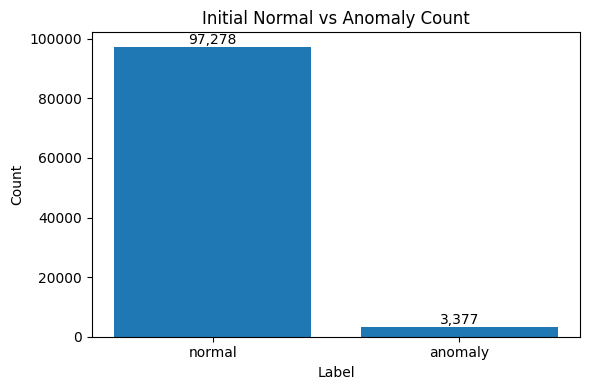

In [32]:
plot_label_distribution(y, title="Initial Normal vs Anomaly Count")

In [33]:
def plot_categorical_distributions(X, categorical_cols, top_n=10):
    """
    문자열 category feature의 분포를 보여줍니다.
    """
    for col in categorical_cols:
        counts = X[col].value_counts().head(top_n)

        plt.figure(figsize=(8, 4))
        plt.bar(counts.index.astype(str), counts.values)
        plt.title(f"Top {top_n} values of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

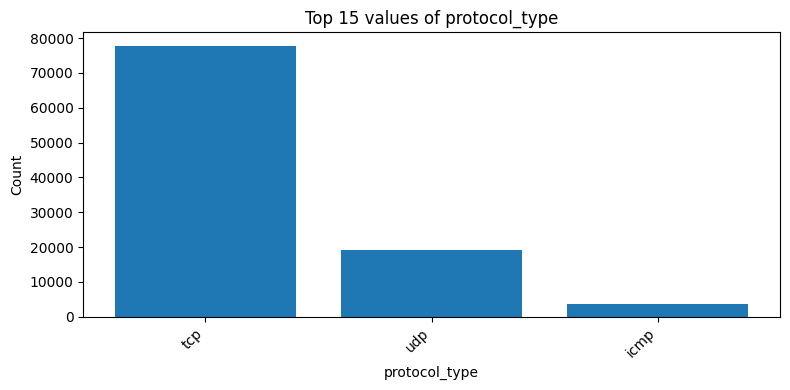

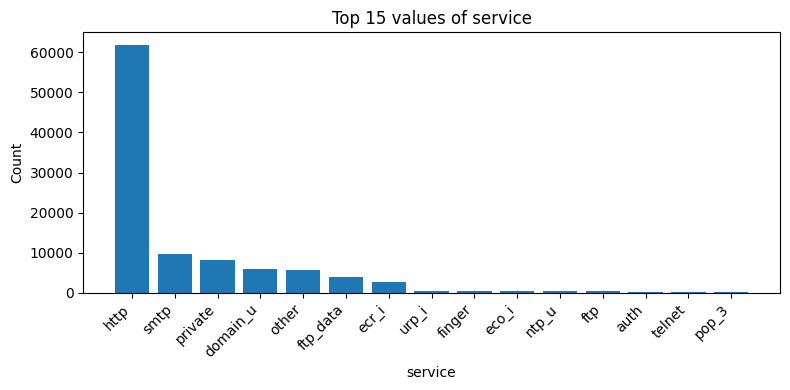

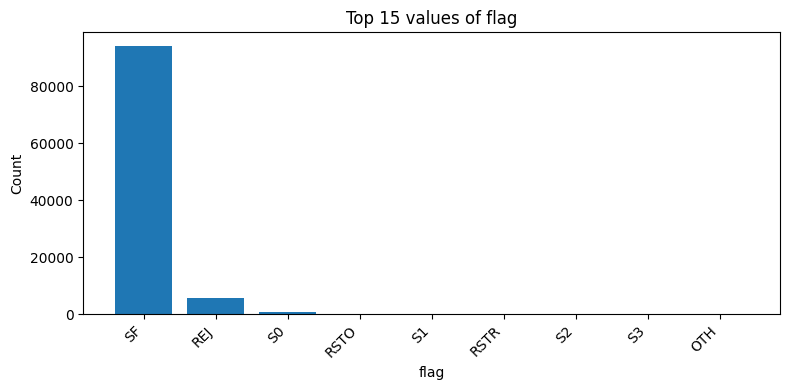

In [34]:
plot_categorical_distributions(X, categorical_cols=categorical_cols, top_n=15)

In [35]:
def plot_numeric_histograms(X, numeric_cols, sample_size=20000):
    """
    주요 숫자형 feature의 분포를 histogram으로 보여줍니다.

    값의 범위가 큰 feature는 log1p 변환 후 시각화합니다.
    log1p(x) = log(1 + x)
    """
    cols_to_plot = [
        "duration",
        "src_bytes",
        "dst_bytes",
        "count",
        "srv_count",
        "serror_rate",
        "same_srv_rate",
        "dst_host_count",
        "dst_host_srv_count",
        "dst_host_same_srv_rate",
    ]

    cols_to_plot = [c for c in cols_to_plot if c in numeric_cols]

    X_sample = X.sample(
        n=min(sample_size, len(X)),
        random_state=RANDOM_STATE
    )

    for col in cols_to_plot:
        values = pd.to_numeric(X_sample[col], errors="coerce").dropna()

        plt.figure(figsize=(7, 4))

        if values.max() > 1000:
            plt.hist(np.log1p(values), bins=50)
            plt.xlabel(f"log1p({col})")
        else:
            plt.hist(values, bins=50)
            plt.xlabel(col)

        plt.title(f"Distribution of {col}")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

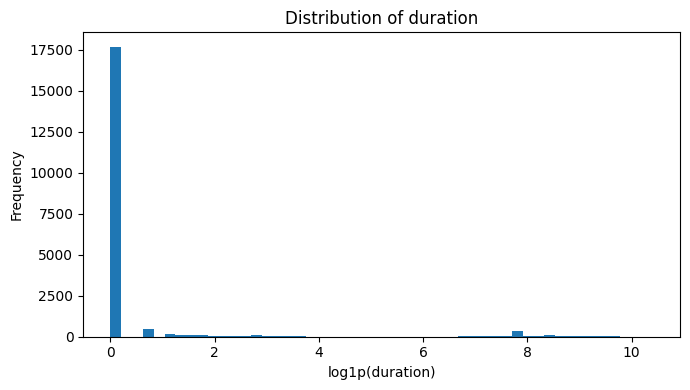

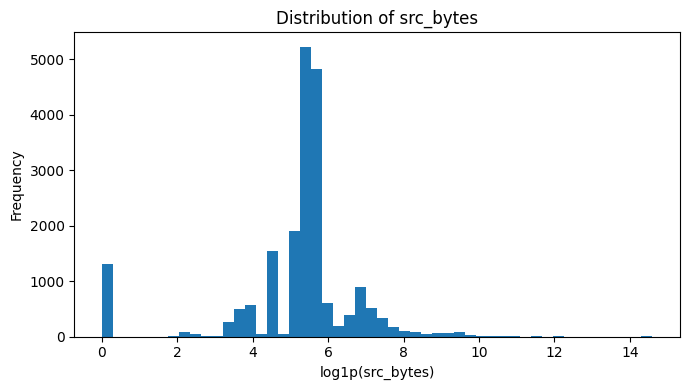

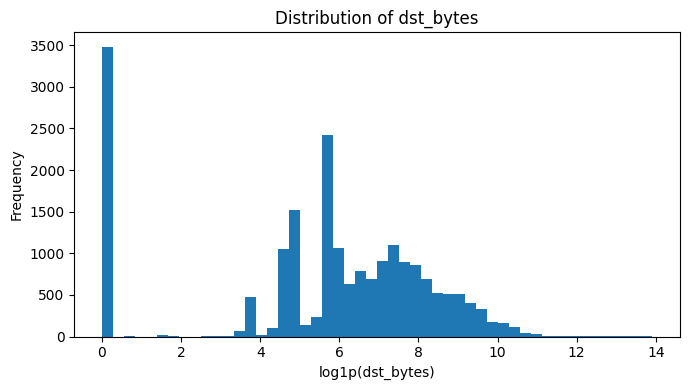

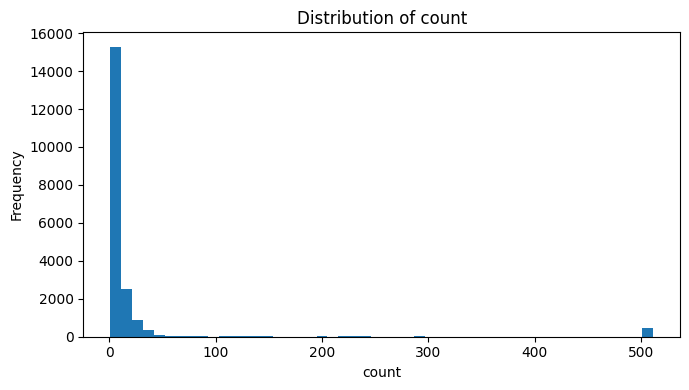

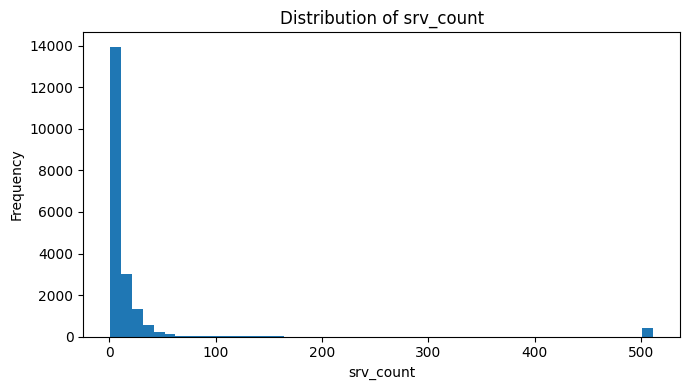

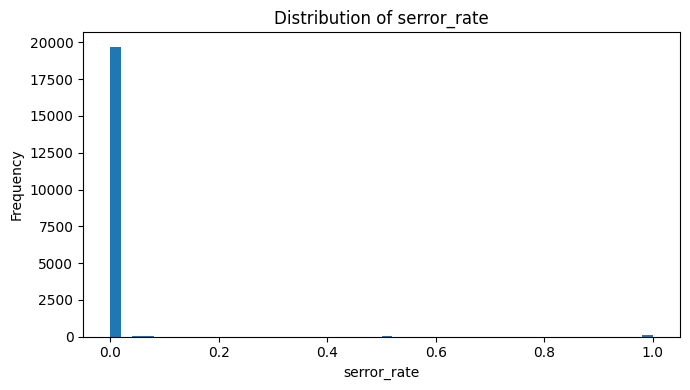

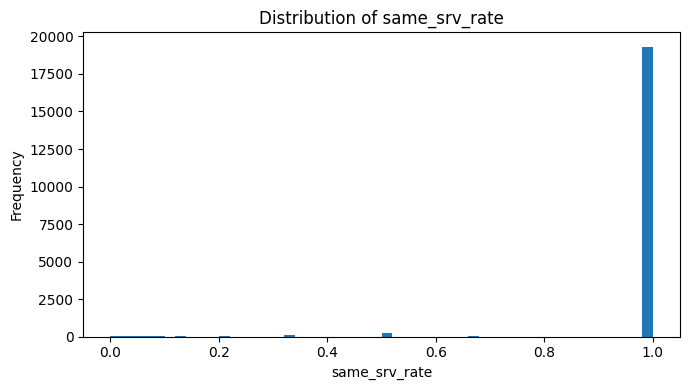

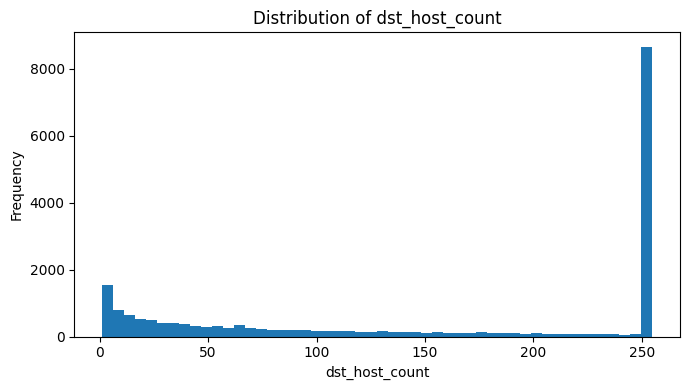

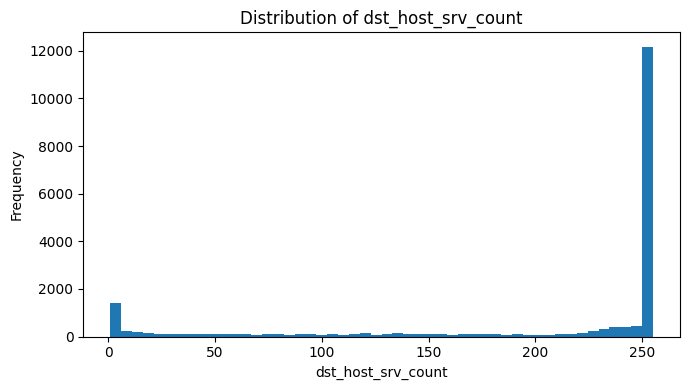

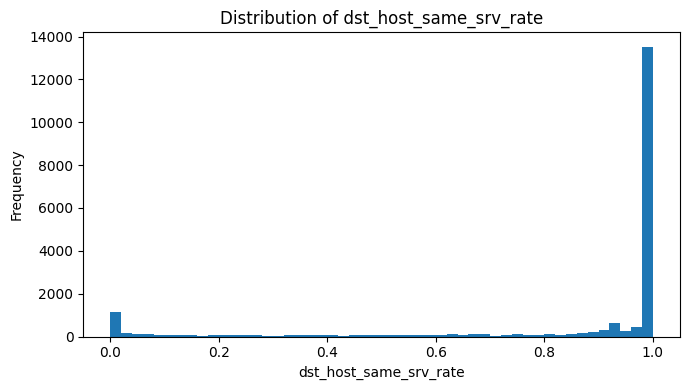

In [36]:
plot_numeric_histograms(X, numeric_cols=numeric_cols, sample_size=20000)

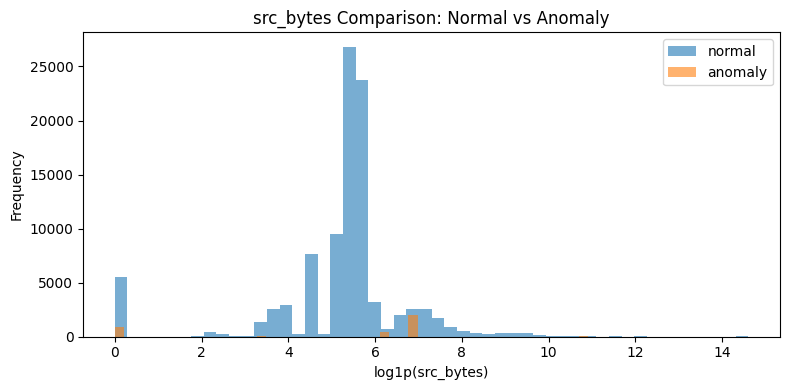

In [37]:
# 정상 vs 이상의 src_bytes 비교
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(X.loc[y == 0, "src_bytes"]), bins=50, alpha=0.6, label="normal")
plt.hist(np.log1p(X.loc[y == 1, "src_bytes"]), bins=50, alpha=0.6, label="anomaly")
plt.title("src_bytes Comparison: Normal vs Anomaly")
plt.xlabel("log1p(src_bytes)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

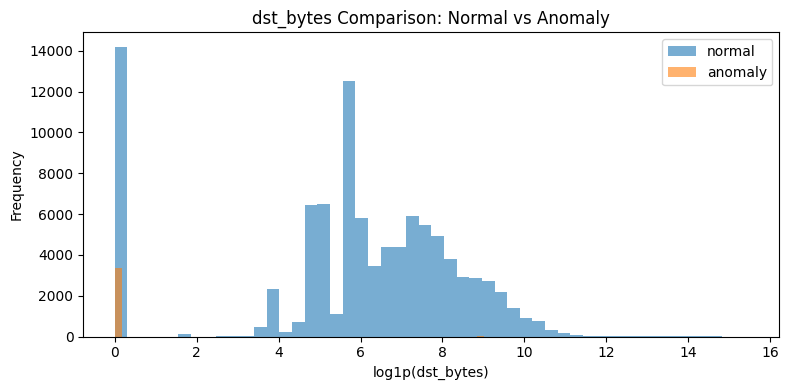

In [38]:
# 정상 vs 이상의 dst_bytes 비교
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(X.loc[y == 0, "dst_bytes"]), bins=50, alpha=0.6, label="normal")
plt.hist(np.log1p(X.loc[y == 1, "dst_bytes"]), bins=50, alpha=0.6, label="anomaly")
plt.title("dst_bytes Comparison: Normal vs Anomaly")
plt.xlabel("log1p(dst_bytes)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# Train / Validation / Test 분리

데이터를 분석할 수 있어야한다. 그래야 어떻게 학습시킬지, 어떤 데이터를 뽑고싶은지 식별 가능

In [39]:
# 전체 데이터를 다음 비율로 나눕니다.
#
# train      : 60%
# validation : 20%
# test       : 20%
#
# train:
# - 모델 학습용
# - 이 중 정상 데이터만 사용해서 IsolationForest 학습
#
# validation:
# - threshold 결정용
# - 모델이 계산한 anomaly score를 보고 어느 점수 이상을 이상으로 볼지 결정
#
# test:
# - 실제 application에서 미래에 들어온 데이터라고 가정
# - 예측할 때는 label을 사용하지 않음
# - 마지막에만 평가를 위해 y_test와 비교
X_temp, X_test, y_temp, y_test, y_raw_temp, y_raw_test = train_test_split(
    X,
    y,
    y_raw,
    test_size=0.2,
    stratify=y, # train/test로 나눌 때 label 비율을 원본 데이터와 비슷하게 유지하라는 의미
    random_state=RANDOM_STATE
)

In [43]:
# temp 80% 중 validation을 25%로 잡으면 전체 기준 20%가 됩니다.
X_train_all, X_val, y_train_all, y_val, y_raw_train, y_raw_val = train_test_split(
    X_temp,
    y_temp,
    y_raw_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

In [44]:
print("[+] Train / Validation / Test 분리 결과")
print("X_train_all:", X_train_all.shape)
print("X_val      :", X_val.shape)
print("X_test     :", X_test.shape)

[+] Train / Validation / Test 분리 결과
X_train_all: (60393, 41)
X_val      : (20131, 41)
X_test     : (20131, 41)


In [45]:
print("[+] Train label 분포:")
print(y_train_all.value_counts().rename({0: "normal", 1: "anomaly"}))
print("\n[+] Train label 분포 비율:")
print(y_train_all.value_counts(normalize=True).rename({0: "normal", 1: "anomaly"}))

[+] Train label 분포:
labels
normal     58366
anomaly     2027
Name: count, dtype: int64

[+] Train label 분포 비율:
labels
normal     0.966437
anomaly    0.033563
Name: proportion, dtype: float64


In [46]:
print("[+] Validation label 분포:")
print(y_val.value_counts().rename({0: "normal", 1: "anomaly"}))
print("\n[+] Validation label 분포 비율:")
print(y_val.value_counts(normalize=True).rename({0: "normal", 1: "anomaly"}))

[+] Validation label 분포:
labels
normal     19456
anomaly      675
Name: count, dtype: int64

[+] Validation label 분포 비율:
labels
normal     0.96647
anomaly    0.03353
Name: proportion, dtype: float64


In [47]:
print("[+] Test label 분포:")
print(y_test.value_counts().rename({0: "normal", 1: "anomaly"}))
print("\n[+] Test label 분포 비율:")
print(y_test.value_counts(normalize=True).rename({0: "normal", 1: "anomaly"}))

[+] Test label 분포:
labels
normal     19456
anomaly      675
Name: count, dtype: int64

[+] Test label 분포 비율:
labels
normal     0.96647
anomaly    0.03353
Name: proportion, dtype: float64


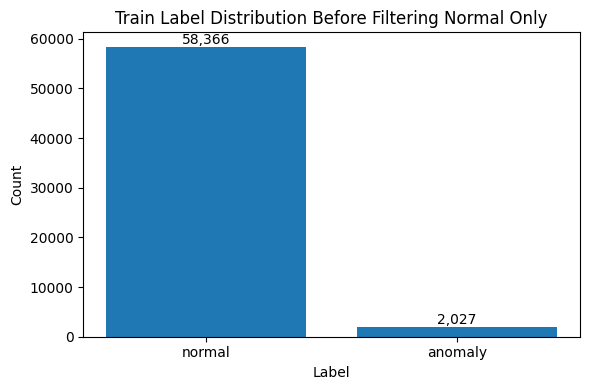

In [48]:
plot_label_distribution(
    y_train_all,
    title="Train Label Distribution Before Filtering Normal Only"
)

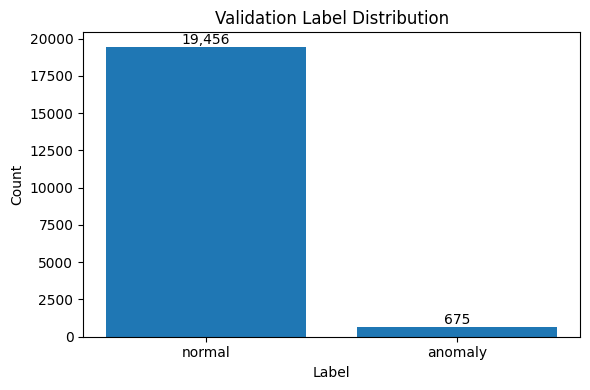

In [49]:
plot_label_distribution(
    y_val,
    title="Validation Label Distribution"
)

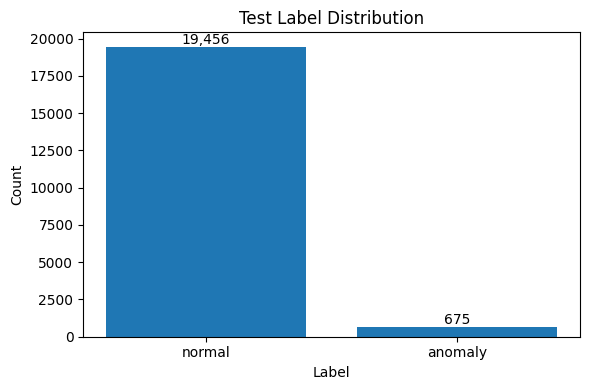

In [50]:
plot_label_distribution(
    y_test,
    title="Test Label Distribution"
)

# train을 위한 정상 데이터

In [51]:
# 이상탐지에서는 공격 데이터를 충분히 모으기 어렵습니다.
#
# 따라서 여기서는:
# - train 데이터에서 정상 데이터만 골라 학습, 정답을 제공하지 않고 원하는 결과를 얻기 위해
# - validation 데이터로 threshold 결정
# - test 데이터는 실제 미래 데이터처럼 예측
#
# 주의:
# validation/test에는 정상과 이상이 모두 들어 있습니다.
# 하지만 test 예측 단계에서는 y_test를 보지 않습니다.

In [52]:
X_train_normal = X_train_all[y_train_all == 0]

In [53]:
# 실습 속도를 위해 정상 학습 데이터를 최대 100,000개까지만 사용합니다.
max_train_size = 100_000

In [54]:
if len(X_train_normal) > max_train_size:
    X_train_normal = X_train_normal.sample(
        n=max_train_size,
        random_state=RANDOM_STATE
    )
print("X_train_normal:", X_train_normal.shape)

X_train_normal: (58366, 41)


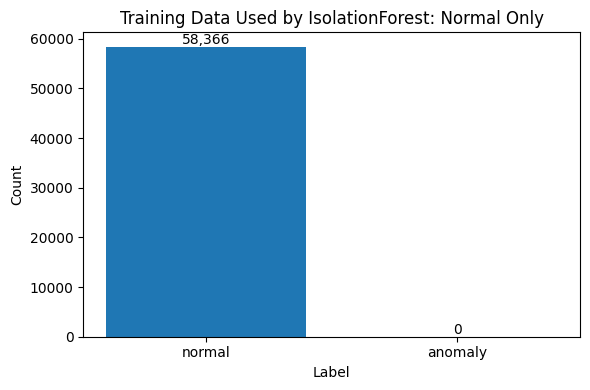

In [55]:
plot_label_distribution(
    np.zeros(len(X_train_normal), dtype=int),
    title="Training Data Used by IsolationForest: Normal Only"
)

# 전처리

In [56]:
# 머신러닝 모델은 문자열을 직접 처리하지 못합니다.
#
# category feature:
# - protocol_type, service, flag
# - OneHotEncoder로 숫자 벡터로 변환
#
# numeric feature:
# - duration, src_bytes, dst_bytes 등
# - StandardScaler로 스케일 조정
#
# with_mean=False:
# - OneHotEncoder 결과가 sparse matrix이므로 sparse 구조를 유지하기 위해 사용

In [58]:
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=True) #OneHotEncoder: 숫자가 아닌 것은 변환, handle_unknown 학습할 때 없었던 데이터는 어떻게 처리할지, 여기서는 ignore로 무시 진행

In [59]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", onehot, categorical_cols),
        ("num", StandardScaler(with_mean=False), numeric_cols), # with_mean=False: 평균은 빼지 않고, 표준편차 σ로만 나눔
    ]
)

# IsolationForest 모델 정의

In [60]:
# IsolationForest 핵심 아이디어:
# - 이상치는 정상 데이터와 패턴이 다릅니다.
# - 이상치는 tree 구조에서 더 빨리 고립되는 경향이 있습니다.
#
# n_estimators=200:
# - isolation tree 개수
# - 많을수록 안정적이지만 느려짐
#
# random_state=42:
# - 재현성을 위한 seed
#
# n_jobs=-1:
# - 가능한 CPU core를 모두 사용

In [61]:
model = IsolationForest(
    n_estimators=200,
    random_state=RANDOM_STATE, #정답이 없어서 랜덤하게 쪼갬, 표본이 적은 곳이 이상 행위로 판단하게 하는 코드
    n_jobs=-1
)

In [62]:
pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", model)
    ]
)

# 모델 학습

In [63]:
pipe.fit(X_train_normal)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num',
                                                  StandardScaler(with_mean=False),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'nu...reations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...])])),
                ('model',
                 IsolationForest(n_estimators=200, n_jobs=-1,
                                 random_state=42))])

In [64]:
print("모델 학습 완료")

X_train_normal_transformed = pipe.named_steps["preprocess"].transform(
    X_train_normal.head(1000)
)
print("전처리 전 feature 개수:", X_train_normal.shape[1])
print("전처리 후 feature 차원 예시:", X_train_normal_transformed.shape)

print("\n해석:")
print("- OneHotEncoder 때문에 feature 수가 늘어납니다.")
print("- 예를 들어 service가 http, smtp, ftp 등 여러 값이면 각각 binary feature로 변환됩니다.")

모델 학습 완료
전처리 전 feature 개수: 41
전처리 후 feature 차원 예시: (1000, 72)

해석:
- OneHotEncoder 때문에 feature 수가 늘어납니다.
- 예를 들어 service가 http, smtp, ftp 등 여러 값이면 각각 binary feature로 변환됩니다.


# Train 정상 데이터의 anomaly score 확인

In [65]:
# 이 단계는 모델이 정상 데이터에 대해 어떤 score 분포를 만드는지 보기 위한 것입니다.

In [70]:
def get_anomaly_score(pipe, X_data):
    """
    IsolationForest의 decision_function을 anomaly score로 변환합니다.

    sklearn IsolationForest:
    - decision_function 값이 클수록 정상에 가까움
    - decision_function 값이 작을수록 이상에 가까움

    우리가 원하는 해석:
    - anomaly_score 값이 클수록 더 이상함

    따라서:
    anomaly_score = -decision_function
    """
    return -pipe.decision_function(X_data) #쓰레스 홀드 지정

In [71]:
train_score_sample = X_train_normal.sample(
    n=min(20000, len(X_train_normal)),
    random_state=RANDOM_STATE
)

In [72]:
train_anomaly_score = get_anomaly_score(pipe, train_score_sample)

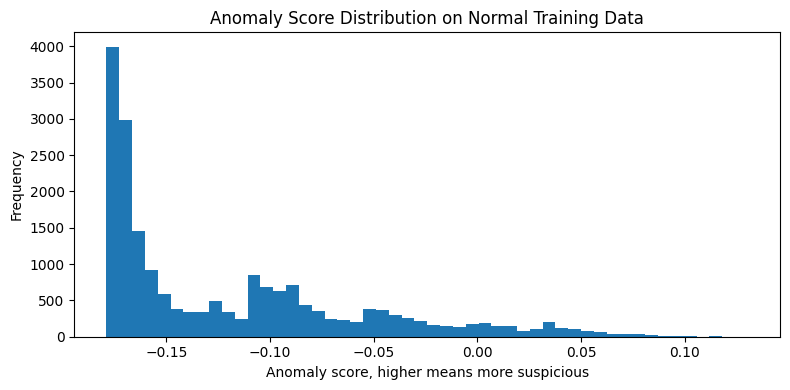


정상 학습 데이터 anomaly score 요약:
count    20000.000000
mean        -0.118866
std          0.063564
min         -0.178889
25%         -0.171134
50%         -0.147270
75%         -0.085732
max          0.130529
dtype: float64


In [73]:
plt.figure(figsize=(8, 4))
plt.hist(train_anomaly_score, bins=50)
plt.title("Anomaly Score Distribution on Normal Training Data")
plt.xlabel("Anomaly score, higher means more suspicious")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("\n정상 학습 데이터 anomaly score 요약:")
print(pd.Series(train_anomaly_score).describe())


# Validation 데이터로 threshold 결정

In [74]:
# validation 데이터는 threshold를 정하는 데 사용합니다.
#
# 모델이 각 connection에 anomaly_score를 부여합니다.
# 그 후 threshold를 하나 정합니다.
#
# 예:
# - anomaly_score >= threshold 이면 anomaly
# - anomaly_score < threshold 이면 normal
#
# 여기서는 validation F1-score가 가장 높은 threshold를 선택합니다.

In [75]:
val_anomaly_score = get_anomaly_score(pipe, X_val)

In [83]:
def find_best_threshold_by_f1(y_true, anomaly_score):
    """
    validation 데이터를 사용해서 threshold를 결정합니다.

    threshold:
    - anomaly_score가 threshold 이상이면 anomaly로 판단
    - anomaly_score가 threshold 미만이면 normal로 판단

    여기서는 F1-score가 가장 높은 threshold를 선택합니다.

    F1-score:
    - precision과 recall의 균형
    - anomaly detection에서 false alarm과 missed attack 사이의 균형을 볼 때 유용
    """
    precision, recall, thresholds = precision_recall_curve(y_true, anomaly_score) # precision_recall_curve: 비정상 임계치를 계산

    # precision, recall은 thresholds보다 길이가 1 더 깁니다.
    # "threshold를 아주 낮게 잡아서 전부 anomaly로 보는 경우"까지 추가로 포함하기 때문입니다.
    # threshold별 F1을 계산하기 위해 마지막 값을 제외합니다.
    precision_for_thresholds = precision[:-1]
    recall_for_thresholds = recall[:-1]

    f1_scores = (
        2 * precision_for_thresholds * recall_for_thresholds
        / (precision_for_thresholds + recall_for_thresholds + 1e-12)
    )

    best_idx = np.argmax(f1_scores)

    best_threshold = thresholds[best_idx]
    best_precision = precision_for_thresholds[best_idx]
    best_recall = recall_for_thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    return best_threshold, best_precision, best_recall, best_f1

In [77]:
best_threshold, best_precision, best_recall, best_f1 = find_best_threshold_by_f1(
    y_true=y_val,
    anomaly_score=val_anomaly_score
)

print("\n==============================")
print("Validation에서 선택한 threshold")
print("==============================")
print(f"best_threshold : {best_threshold:.6f}")
print(f"precision      : {best_precision:.4f}")
print(f"recall         : {best_recall:.4f}")
print(f"f1             : {best_f1:.4f}")



Validation에서 선택한 threshold
best_threshold : 0.029259
precision      : 0.4600
recall         : 0.9881
f1             : 0.6278


In [78]:
# validation 예측
val_pred = (val_anomaly_score >= best_threshold).astype(int)

In [80]:
print("[+] Classification Report")
print(classification_report(
    y_val,
    val_pred,
    target_names=["normal", "anomaly"], #macro avg를 봐야한다.
    digits=4
))

[+] Classification Report
              precision    recall  f1-score   support

      normal     0.9996    0.9598    0.9793     19456
     anomaly     0.4600    0.9881    0.6278       675

    accuracy                         0.9607     20131
   macro avg     0.7298    0.9740    0.8035     20131
weighted avg     0.9815    0.9607    0.9675     20131



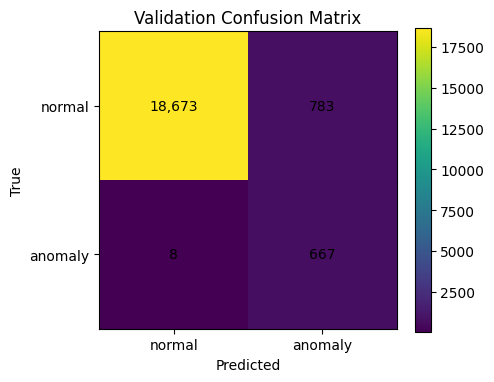

In [81]:
val_cm = confusion_matrix(y_val, val_pred)
plot_confusion_matrix(
    val_cm,
    title="Validation Confusion Matrix"
)

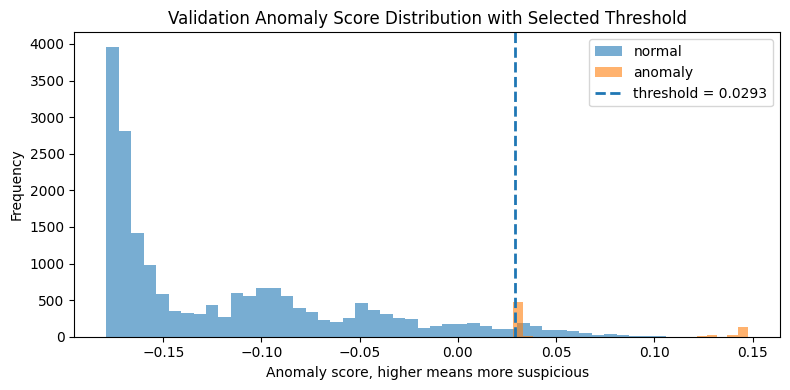

In [82]:
plot_score_distribution_with_threshold(
    scores=val_anomaly_score,
    y_true=y_val,
    threshold=best_threshold,
    title="Validation Anomaly Score Distribution with Selected Threshold"
)

# Test 데이터를 실제 application의 미래 데이터라고 가정

In [ ]:
# 이제 test 데이터는 미래에 새로 들어온 네트워크 connection이라고 가정합니다.
#
# 실제 application 상황:
# - 새 데이터에는 label이 없습니다.
# - 모델은 X_test_app만 보고 normal/anomaly를 판단해야 합니다.
#
# 그래서 아래 예측 함수에는 y_test를 넣지 않습니다.

In [84]:
X_test_app = X_test.copy()

In [86]:
def predict_with_threshold(pipe, X_new, threshold):
    """
    실제 application에서 사용할 예측 함수입니다.

    입력:
    - pipe: 학습 완료된 preprocessing + IsolationForest pipeline
    - X_new: 새로 들어온 네트워크 connection 데이터
    - threshold: validation에서 결정한 anomaly threshold

    출력:
    - anomaly_score
    - predicted_label
    - predicted_class

    predicted_label:
    - 0 = normal
    - 1 = anomaly
    """
    scores = get_anomaly_score(pipe, X_new)
    predicted_label = (scores >= threshold).astype(int)
    predicted_class = np.where(predicted_label == 1, "anomaly", "normal")

    return pd.DataFrame({
        "anomaly_score": scores,
        "predicted_label": predicted_label,
        "predicted_class": predicted_class
    })

In [87]:
application_predictions = predict_with_threshold(
    pipe=pipe,
    X_new=X_test_app,
    threshold=best_threshold
)

In [88]:
print("[+] Application 예측 결과 앞부분 20개")
print(application_predictions.head(20))

[+] Application 예측 결과 앞부분 20개
    anomaly_score  predicted_label predicted_class
0       -0.151704                0          normal
1       -0.158534                0          normal
2       -0.160584                0          normal
3       -0.170656                0          normal
4       -0.081130                0          normal
5       -0.177432                0          normal
6       -0.163055                0          normal
7       -0.176160                0          normal
8       -0.105061                0          normal
9        0.145221                1         anomaly
10      -0.164913                0          normal
11      -0.167361                0          normal
12      -0.127890                0          normal
13      -0.172373                0          normal
14      -0.165249                0          normal
15      -0.173433                0          normal
16      -0.050577                0          normal
17      -0.125864                0          normal
1